In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv("SalaryPrediction.csv")

In [3]:
df.head()

,Wage,Age,Club,League,Nation,Position,Apps,Caps
0,"46,427,000",23,PSG,Ligue 1 Uber Eats,FRA,Forward,190,57
1,"42,125,000",30,PSG,Ligue 1 Uber Eats,BRA,Midfilder,324,119
2,"34,821,000",35,PSG,Ligue 1 Uber Eats,ARG,Forward,585,162
3,"19,959,000",31,R. Madrid,La Liga,BEL,Forward,443,120
4,"19,500,000",31,Man UFC,Premier League,ESP,Goalkeeper,480,45


In [4]:
df.tail()

,Wage,Age,Club,League,Nation,Position,Apps,Caps
3902,"3,400",19,Vigo,La Liga,ESP,Defender,0,0
3903,"3,200",18,Famalicao,Primiera Liga,BRA,Goalkeeper,0,0
3904,"2,900",18,Vigo,La Liga,ESP,Forward,0,0
3905,"2,700",18,Vigo,La Liga,ESP,Defender,0,0
3906,"1,400",18,Vigo,La Liga,ESP,Defender,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3907 entries, 0 to 3906
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Wage      3907 non-null   str  
 1   Age       3907 non-null   int64
 2   Club      3907 non-null   str  
 3   League    3907 non-null   str  
 4   Nation    3907 non-null   str  
 5   Position  3907 non-null   str  
 6   Apps      3907 non-null   int64
 7   Caps      3907 non-null   int64
dtypes: int64(3), str(5)
memory usage: 244.3 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,3907.0,24.120553,4.935638,18.0,20.0,24.0,28.0,41.0
Apps,3907.0,140.057077,131.694425,0.0,15.0,115.0,224.5,715.0
Caps,3907.0,8.926542,20.518234,0.0,0.0,0.0,6.0,180.0


In [7]:
df.isnull().sum()

Wage        0
Age         0
Club        0
League      0
Nation      0
Position    0
Apps        0
Caps        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(65)

In [9]:
df.drop_duplicates(inplace= True)
df.duplicated().sum()

np.int64(0)

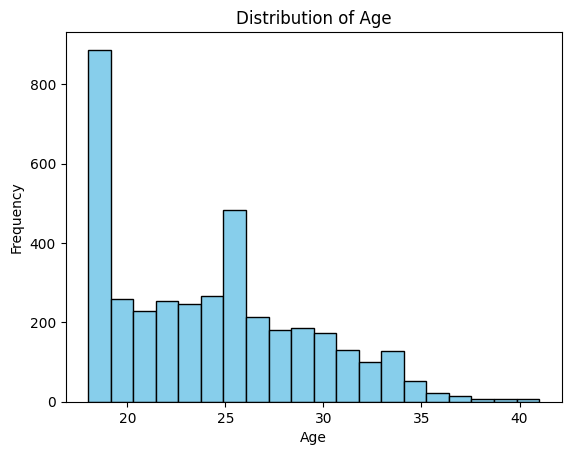

In [10]:
plt.hist(df["Age"], bins = 20, color = "skyblue", edgecolor = "black")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [11]:
df["Wage"] = df["Wage"].replace({"," : ""}, regex = True).astype(int)

In [12]:
df["Wage"][0]

np.int64(46427000)

In [13]:
df.groupby("Position")["Wage"].mean()

Position
Defender      1.332659e+06
Forward       1.352223e+06
Goalkeeper    1.019950e+06
Midfilder     1.630598e+06
Name: Wage, dtype: float64

In [14]:
df["Club"].value_counts()

Club
MRT           64
BRG           60
VIZ           55
Chelsea       52
Leicester     51
              ..
LOSC          21
OL            21
FC Lorient    21
PSG           20
Clermont      18
Name: count, Length: 116, dtype: int64

In [15]:
top_nations = df["Nation"].value_counts().head(10)

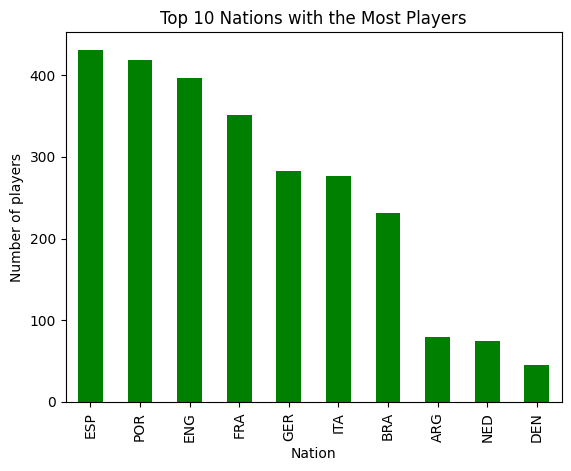

In [16]:
top_nations.plot(kind = "bar", color = "green")
plt.title("Top 10 Nations with the Most Players")
plt.xlabel("Nation")
plt.ylabel("Number of players")
plt.show()

In [17]:
df["League"].value_counts()

League
Premier League       861
Primiera Liga        736
Serie A              669
La Liga              573
Bundesliga           542
Ligue 1 Uber Eats    461
Name: count, dtype: int64

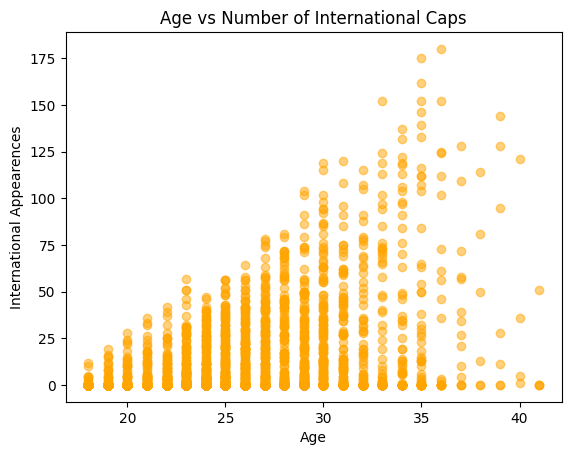

In [18]:
plt.scatter(df["Age"], df["Caps"], alpha = 0.5, color = "orange")
plt.title("Age vs Number of International Caps")
plt.xlabel("Age")
plt.ylabel("International Appearences")
plt.show()

In [19]:
df.groupby("Club").agg({"Apps": "sum", "Age": "mean"}).reset_index().sort_values(by = "Apps", ascending = False)

,Club,Apps,Age
68,Nottm Forest,8593,24.820000
53,Inter,7080,26.312500
26,Cadiz,6875,26.606061
64,Man UFC,6692,23.565217
79,Real Hispalis,6584,27.206897
...,...,...,...
109,VfB Stuttgart,3054,22.366667
103,VIZ,3040,21.345455
81,Reims,2984,24.590909
14,BVT,2974,24.517241


In [20]:
df.groupby("Position").agg({"Wage": "mean", "Caps": "mean"}).sort_values(by = "Wage", ascending = False)

,Wage,Caps
Position,,
Midfilder,1.630598e+06,10.233333
Forward,1.352223e+06,8.906212
Defender,1.332659e+06,8.821625
Goalkeeper,1.019950e+06,7.200466


In [21]:
top_clubs_average_age = df.groupby("Club")["Age"].mean().nlargest(5)

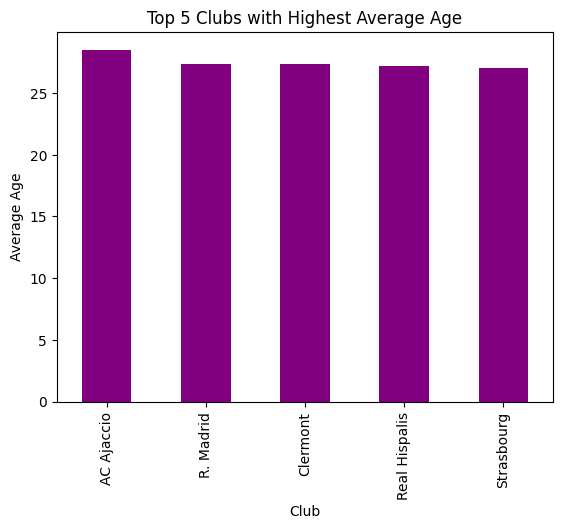

In [22]:
top_clubs_average_age.plot(kind = "bar", color = "purple")
plt.title("Top 5 Clubs with Highest Average Age")
plt.xlabel("Club")
plt.ylabel("Average Age")
plt.show()

In [23]:
league_distribution = df["League"].value_counts()

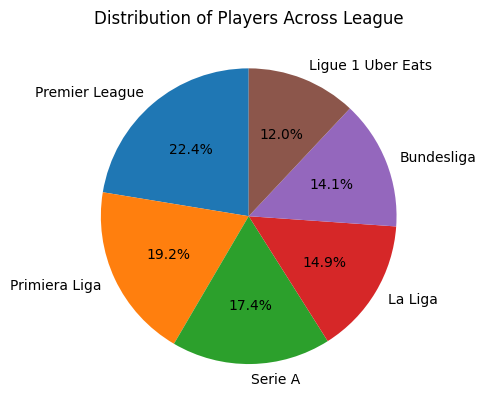

In [24]:
plt.pie(league_distribution, labels = league_distribution.index, autopct= "%1.1f%%", startangle=90)
plt.title("Distribution of Players Across League")
plt.show()

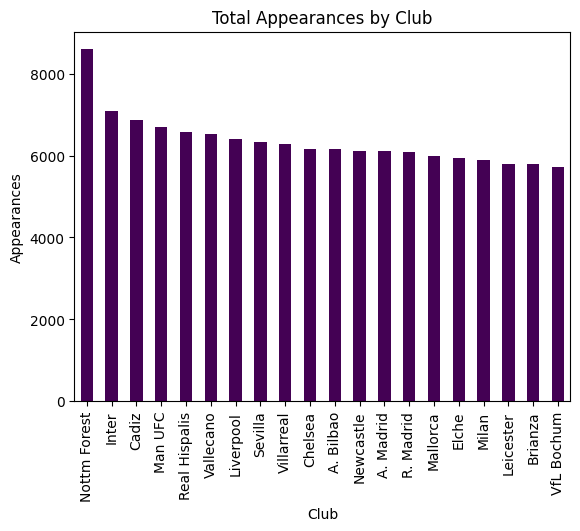

In [26]:
club_apps = df.groupby("Club")["Apps"].sum().sort_values(ascending=False).head(20)
club_apps.plot(kind = "bar", stacked = True, colormap = "viridis")
plt.title("Total Appearances by Club")
plt.xlabel("Club")
plt.ylabel("Appearances")
plt.show()

In [31]:
df = pd.read_csv("SalaryPrediction.csv")

In [32]:
df

,Wage,Age,Club,League,Nation,Position,Apps,Caps
0,"46,427,000",23,PSG,Ligue 1 Uber Eats,FRA,Forward,190,57
1,"42,125,000",30,PSG,Ligue 1 Uber Eats,BRA,Midfilder,324,119
2,"34,821,000",35,PSG,Ligue 1 Uber Eats,ARG,Forward,585,162
3,"19,959,000",31,R. Madrid,La Liga,BEL,Forward,443,120
4,"19,500,000",31,Man UFC,Premier League,ESP,Goalkeeper,480,45
...,...,...,...,...,...,...,...,...
3902,"3,400",19,Vigo,La Liga,ESP,Defender,0,0
3903,"3,200",18,Famalicao,Primiera Liga,BRA,Goalkeeper,0,0
3904,"2,900",18,Vigo,La Liga,ESP,Forward,0,0
3905,"2,700",18,Vigo,La Liga,ESP,Defender,0,0


In [33]:
df = df[["Age", "League", "Apps", "Caps", "Wage"]]

In [34]:
df

,Age,League,Apps,Caps,Wage
0,23,Ligue 1 Uber Eats,190,57,"46,427,000"
1,30,Ligue 1 Uber Eats,324,119,"42,125,000"
2,35,Ligue 1 Uber Eats,585,162,"34,821,000"
3,31,La Liga,443,120,"19,959,000"
4,31,Premier League,480,45,"19,500,000"
...,...,...,...,...,...
3902,19,La Liga,0,0,"3,400"
3903,18,Primiera Liga,0,0,"3,200"
3904,18,La Liga,0,0,"2,900"
3905,18,La Liga,0,0,"2,700"


In [35]:
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
labelencoder = preprocessing.LabelEncoder()

df["League"] = labelencoder.fit_transform(df["League"])

In [36]:
df

,Age,League,Apps,Caps,Wage
0,23,2,190,57,"46,427,000"
1,30,2,324,119,"42,125,000"
2,35,2,585,162,"34,821,000"
3,31,1,443,120,"19,959,000"
4,31,3,480,45,"19,500,000"
...,...,...,...,...,...
3902,19,1,0,0,"3,400"
3903,18,4,0,0,"3,200"
3904,18,1,0,0,"2,900"
3905,18,1,0,0,"2,700"


In [37]:
df["Wage"] = df["Wage"].replace({"," : ""}, regex = True).astype(int)

In [38]:
df

,Age,League,Apps,Caps,Wage
0,23,2,190,57,46427000
1,30,2,324,119,42125000
2,35,2,585,162,34821000
3,31,1,443,120,19959000
4,31,3,480,45,19500000
...,...,...,...,...,...
3902,19,1,0,0,3400
3903,18,4,0,0,3200
3904,18,1,0,0,2900
3905,18,1,0,0,2700


In [39]:
X = df.iloc[:, :-1]

In [40]:
X

,Age,League,Apps,Caps
0,23,2,190,57
1,30,2,324,119
2,35,2,585,162
3,31,1,443,120
4,31,3,480,45
...,...,...,...,...
3902,19,1,0,0
3903,18,4,0,0
3904,18,1,0,0
3905,18,1,0,0


In [41]:
y = df.iloc[:, -1]

In [42]:
y

0       46427000
1       42125000
2       34821000
3       19959000
4       19500000
          ...   
3902        3400
3903        3200
3904        2900
3905        2700
3906        1400
Name: Wage, Length: 3907, dtype: int64

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

In [45]:
X_train

,Age,League,Apps,Caps
575,26,3,167,1
482,23,3,167,30
3773,19,4,0,0
734,24,5,182,33
455,27,5,178,3
...,...,...,...,...
285,25,3,197,37
3428,18,0,0,0
2483,25,1,224,0
1950,21,1,99,0


In [46]:
X_test

,Age,League,Apps,Caps
1441,24,2,211,0
3681,18,4,0,0
2188,27,2,157,27
599,26,3,276,0
3541,18,3,2,0
...,...,...,...,...
1585,25,1,152,0
1260,29,3,120,0
3802,18,1,0,0
2412,18,0,0,0


In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_X_test = scaler.fit_transform(X_test)
scaled_X_train = scaler.fit_transform(X_train)

In [48]:
scaled_X_test

array([[-0.00697092, -0.36618052,  0.56033357, -0.4217098 ],
       [-1.21836174,  0.84206069, -1.05416997, -0.4217098 ],
       [ 0.59872449, -0.36618052,  0.14714309,  0.93581126],
       ...,
       [-1.21836174, -0.97030113, -1.05416997, -0.4217098 ],
       [-1.21836174, -1.57442174, -1.05416997, -0.4217098 ],
       [-0.8145648 ,  0.84206069, -0.67923787, -0.4217098 ]],
      shape=(782, 4))

In [49]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def model_results(predictions):
        print("Mean absolute error on model is {}".format(mean_absolute_error(y_test, predictions)))
        print("Root mean squared error on model is {}".format(np.sqrt(mean_squared_error(y_test, predictions))))

In [51]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(scaled_X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-939764.79, -48413.52,1295683.91,1193046.95]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.354e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[85.1 ,55.61,44.18,14.65]"


In [53]:
predictions = lr.predict(scaled_X_test)

In [54]:
model_results(predictions)

Mean absolute error on model is 1123665.895027932
Root mean squared error on model is 1947825.424365279


In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

In [56]:
svrmodel = SVR()

In [57]:
param_grid_svr = {"C" : [0.01, 0.1, 0.5], "kernel": ["linear", "rbf", "poly"], "degree": [2,3,4]}

In [59]:
grid_svr = GridSearchCV(svrmodel,param_grid_svr)

In [60]:
grid_svr.fit(scaled_X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'degree': [2, 3, ...], 'kernel': ['linear', 'rbf', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the verbosity of information 

In [61]:
print("Best parameters for model is {}".format(grid_svr.best_params_))

Best parameters for model is {'C': 0.5, 'degree': 4, 'kernel': 'poly'}


In [62]:
svr_predictions = grid_svr.predict(scaled_X_test)

In [63]:
model_results(svr_predictions)

Mean absolute error on model is 1306431.1947672807
Root mean squared error on model is 2707454.3722703066


In [64]:
from sklearn.ensemble import RandomForestRegressor

In [65]:
rf = RandomForestRegressor()

In [66]:
param_grid_rf = {"max_depth": [5,10,15], "max_features": ["auto", "log2"], "n_estimators" :[2,5,7,10] }

In [67]:
grid_rf = GridSearchCV(rf, param_grid_rf)

In [68]:
grid_rf.fit(scaled_X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'max_features': ['auto', 'log2'], 'n_estimators': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls t

In [69]:
print("Best parameters for model is {}".format(grid_rf.best_params_))

Best parameters for model is {'max_depth': 5, 'max_features': 'log2', 'n_estimators': 10}


In [70]:
pred_rf = grid_rf.predict(scaled_X_test)
model_results(pred_rf)

Mean absolute error on model is 966638.4258714758
Root mean squared error on model is 1843836.7750223554
